In [1]:
print('c')

c


In [26]:
import torch
import torch.nn as nn
from torchvision import models
from torch.nn.functional import relu
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch.optim as optim
from torch.utils.data import random_split
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np

In [2]:
print(f"Доступен ли CUDA (GPU): {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Имя видеокарты: {torch.cuda.get_device_name(0)}")
    print(f"Версия CUDA в PyTorch: {torch.version.cuda}")

Доступен ли CUDA (GPU): True
Имя видеокарты: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Версия CUDA в PyTorch: 13.2


In [22]:
# ==========================================
# 1. АРХИТЕКТУРА СЕТИ: U-Net для Сегментации
# ==========================================
class DoubleConv(nn.Module):
    """(Конволюция => BatchNorm => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(128, 64)
        
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        x = self.up1(x4)
        x = self.conv1(torch.cat([x, x3], dim=1))
        x = self.up2(x)
        x = self.conv2(torch.cat([x, x2], dim=1))
        x = self.up3(x)
        x = self.conv3(torch.cat([x, x1], dim=1))
        
        logits = self.outc(x)
        return logits

# ==========================================
# 2. ПРЕДОБРАБОТКА И ЗАГРУЗКА ДАННЫХ (Dataset)
# ==========================================
class ForestDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        
        # Списки для хранения только реально существующих пар
        self.valid_images = []
        self.valid_masks = []
        
        all_raw_images = os.listdir(images_dir)
        print(f"Найдено исходных снимков в папке images: {len(all_raw_images)}")
        
        # 🔥 Валидация датасета при инициализации
        for img_name in all_raw_images:
            img_path = os.path.join(images_dir, img_name)
            
            # Составляем имя ожидаемой маски
            mask_base = img_name.replace("_sat", "_mask")
            base_name, _ = os.path.splitext(mask_base)
            
            # Проверяем оба популярных расширения
            possible_mask_paths = [
                os.path.join(masks_dir, base_name + ".jpg"),
                os.path.join(masks_dir, base_name + ".png")
            ]
            
            mask_found = False
            for path in possible_mask_paths:
                if os.path.exists(path):
                    self.valid_images.append(img_path)
                    self.valid_masks.append(path)
                    mask_found = True
                    break
                    
        print(f"Успешно сопоставлено пар (Снимок <-> Маска): {len(self.valid_images)}")
        if len(all_raw_images) - len(self.valid_images) > 0:
            print(f"⚠️ Пропущено файлов без масок: {len(all_raw_images) - len(self.valid_images)}")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, index):
        img_path = self.valid_images[index]
        mask_path = self.valid_masks[index]
        
        # Загрузка проверенных файлов
        image = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32) / 255.0
        mask = np.where(mask > 0.5, 1.0, 0.0)

        if self.transform:
            # Albumentations требует передачи именованных аргументов
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
            
        # В ЛЮБОМ СЛУЧАЕ переводим в тензоры PyTorch [C, H, W]
        if isinstance(image, np.ndarray):
            image = torch.tensor(image).permute(2, 0, 1)
        if isinstance(mask, np.ndarray):
            mask = torch.tensor(mask).unsqueeze(0)
            
        return image, mask


train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),                  # Отражение по горизонтали
    A.VerticalFlip(p=0.5),                    # Отражение по вертикали
    A.RandomRotate90(p=0.5),                  # Поворот на 90, 180 или 270 градусов
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5), # Небольшой сдвиг и наклон
    A.RandomBrightnessContrast(p=0.2),        # Случайное изменение яркости (имитация облачности/солнца)
])
# Инициализация
dataset = ForestDataset(
    images_dir="../data/ForestS/images/", 
    masks_dir="../data/ForestS/masks/",
    transform=train_transform 
)

loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

# ==========================================
# 3. НАСТРОЙКА КОМБИНИРОВАННОЙ ФУНКЦИИ ПОТЕРЬ
# ==========================================
class BCEDiceLoss(nn.Module):
    def __init__(self, weight_bce=0.5, weight_dice=0.5):
        super().__init__()
        self.weight_bce = weight_bce
        self.weight_dice = weight_dice
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        
        pred_sigmoid = torch.sigmoid(pred)
        smooth = 1e-5
        
        intersection = (pred_sigmoid * target).sum(dim=(2, 3))
        dice_loss = 1 - ((2. * intersection + smooth) / (pred_sigmoid.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth))
        
        return self.weight_bce * bce_loss + self.weight_dice * dice_loss.mean()


Найдено исходных снимков в папке images: 5108
Успешно сопоставлено пар (Снимок <-> Маска): 5108


In [23]:
# 1. Проверяем доступность видеокарты
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")
if device.type == 'cuda':
    print(f"Активная GPU: {torch.cuda.get_device_name(0)}")

# 2. Разделяем выборку на обучение (80%) и валидацию (20%)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Уменьшаем batch_size до 8, чтобы уложиться в 4 ГБ видеопамяти ноутбука
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

# 3. Создаем модель и лосс-функцию
model = UNet(in_channels=3, out_channels=1).to(device)
criterion = BCEDiceLoss(weight_bce=0.5, weight_dice=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Путь, куда сохранится обученная модель
MODEL_SAVE_PATH = "../models/unet_forest.pt"

Используем устройство: cuda
Активная GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [25]:
num_epochs = 30  
best_val_loss = float('inf')

# --- НАСТРОЙКИ EARLY STOPPING ---
patience = 5  # Количество эпох без улучшений, после которого обучение остановится
patience_counter = 0  # Счетчик эпох без улучшений

# Инструмент для смешанной точности (Mixed Precision)
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

print("Старт обучения на GPU со всеми метриками и Early Stopping...")

for epoch in range(num_epochs):
    # ==========================================
    # 1. СТАДИЯ ОБУЧЕНИЯ (TRAIN)
    # ==========================================
    model.train()
    train_loss = 0.0
    train_total_dice = 0.0
    train_total_iou = 0.0
    smooth = 1e-5
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Запускаем autocast для ускорения на видеокарте
        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, masks)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        
        # Расчет метрик для Train батча
        preds = (torch.sigmoid(outputs) > 0.5).float()
        intersection = (preds * masks).sum(dim=(2, 3))
        union = preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) - intersection
        
        batch_dice = (2. * intersection + smooth) / (preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) + smooth)
        batch_iou = (intersection + smooth) / (union + smooth)
        
        train_total_dice += batch_dice.mean().item()
        train_total_iou += batch_iou.mean().item()
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_dice = train_total_dice / len(train_loader)
    avg_train_iou = train_total_iou / len(train_loader)
    
    # ==========================================
    # 2. СТАДИЯ ВАЛИДАЦИИ (VALIDATION)
    # ==========================================
    model.eval()
    val_loss = 0.0
    val_total_dice = 0.0
    val_total_iou = 0.0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, masks)
                
            val_loss += loss.item()
            
            # Расчет метрик для Val батча
            preds = (torch.sigmoid(outputs) > 0.5).float()
            intersection = (preds * masks).sum(dim=(2, 3))
            union = preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) - intersection
            
            batch_dice = (2. * intersection + smooth) / (preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) + smooth)
            batch_iou = (intersection + smooth) / (union + smooth)
            
            val_total_dice += batch_dice.mean().item()
            val_total_iou += batch_iou.mean().item()
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_total_dice / len(val_loader)
    avg_val_iou = val_total_iou / len(val_loader)
    
    # Вывод логов в консоль
    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f} | "
          f"Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")
    
    # ==========================================
    # 3. ЛОГИКА EARLY STOPPING И СОХРАНЕНИЯ
    # ==========================================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(" -> saved best model")
        patience_counter = 0  # Сбрасываем счетчик, так как лосс уменьшился
    else:
        patience_counter += 1  # Модель не улучшилась на валидации
        print(f" -> Лосс на валидации не улучшился. Ожидание: {patience_counter}/{patience}")
        
        # Если вышли на плато дольше, чем значение patience — останавливаем цикл
        if patience_counter >= patience:
            print(f"\n🛑 Обучение остановлено! Модель вышла на плато и не улучшается {patience} эпох(и) подряд.")
            break

Старт обучения на GPU со всеми метриками и Early Stopping...
Epoch 01/30 | Train Loss: 0.4318 | Val Loss: 0.4168 | Train Dice: 0.7104 | Val Dice: 0.7159 | Train IoU: 0.6192 | Val IoU: 0.6269
 -> saved best model
Epoch 02/30 | Train Loss: 0.4256 | Val Loss: 0.4088 | Train Dice: 0.7149 | Val Dice: 0.7313 | Train IoU: 0.6239 | Val IoU: 0.6446
 -> saved best model
Epoch 03/30 | Train Loss: 0.4195 | Val Loss: 0.4185 | Train Dice: 0.7179 | Val Dice: 0.7273 | Train IoU: 0.6273 | Val IoU: 0.6414
 -> Лосс на валидации не улучшился. Ожидание: 1/5
Epoch 04/30 | Train Loss: 0.4177 | Val Loss: 0.4075 | Train Dice: 0.7195 | Val Dice: 0.7246 | Train IoU: 0.6295 | Val IoU: 0.6377
 -> saved best model
Epoch 05/30 | Train Loss: 0.4124 | Val Loss: 0.4046 | Train Dice: 0.7232 | Val Dice: 0.7275 | Train IoU: 0.6334 | Val IoU: 0.6413
 -> saved best model
Epoch 06/30 | Train Loss: 0.4040 | Val Loss: 0.4082 | Train Dice: 0.7264 | Val Dice: 0.7354 | Train IoU: 0.6380 | Val IoU: 0.6496
 -> Лосс на валидации не 

KeyboardInterrupt: 

Генерация тестовых предсказаний на валидационной выборке...


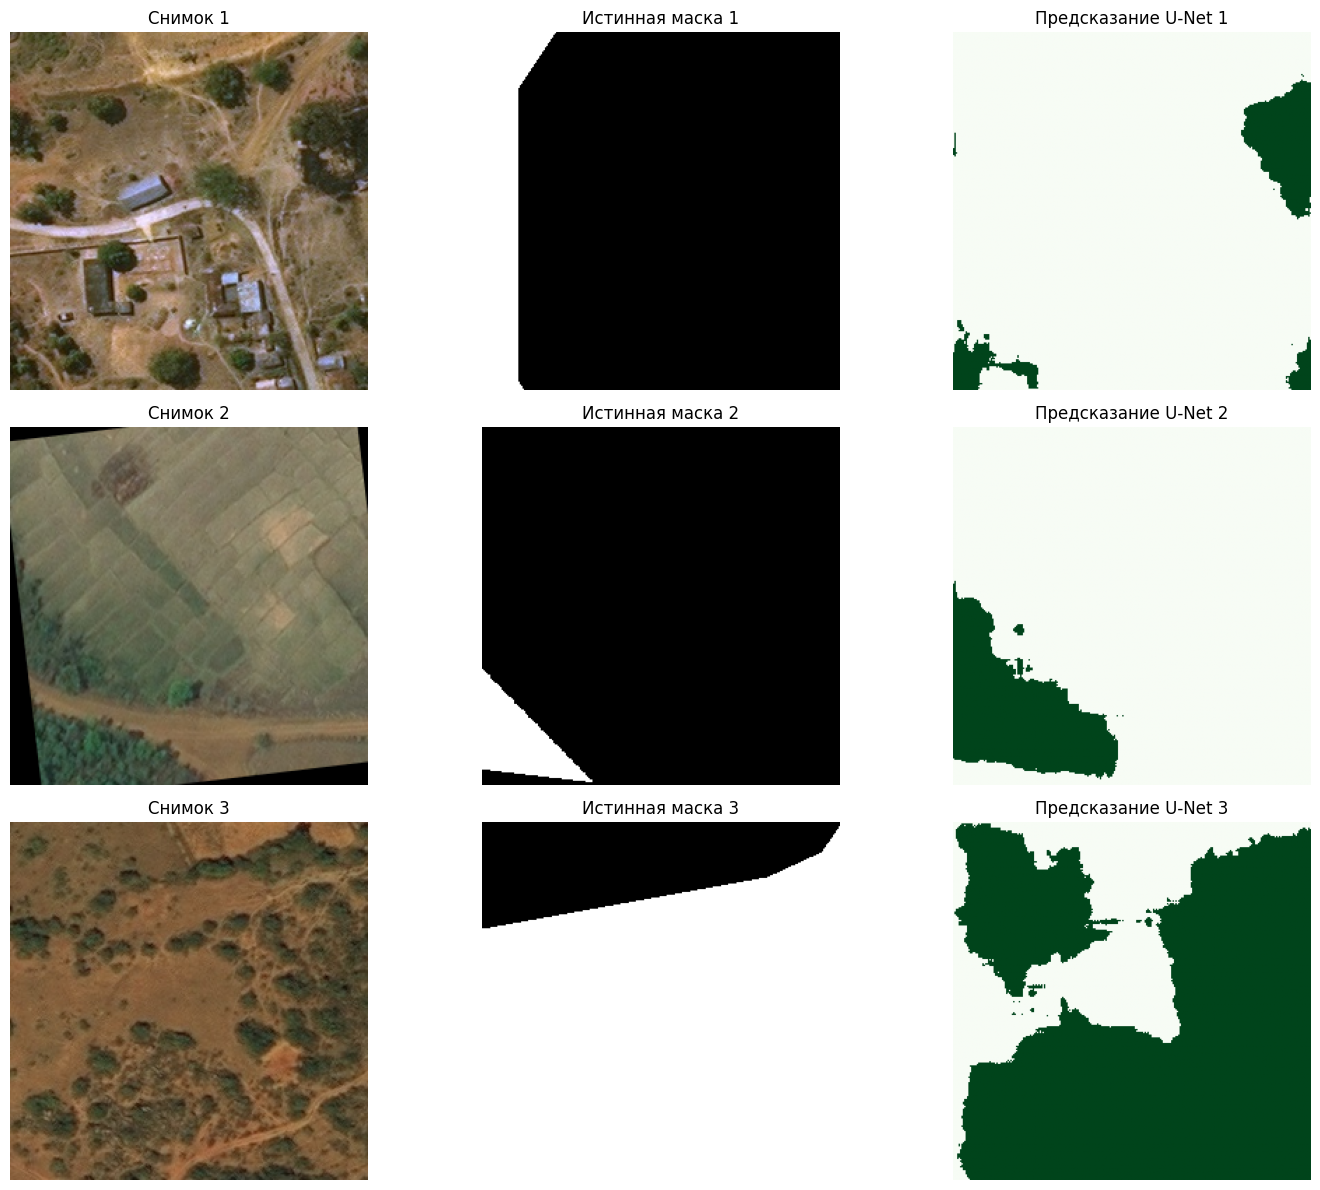


Отрисовка графиков метрик процесса обучения...


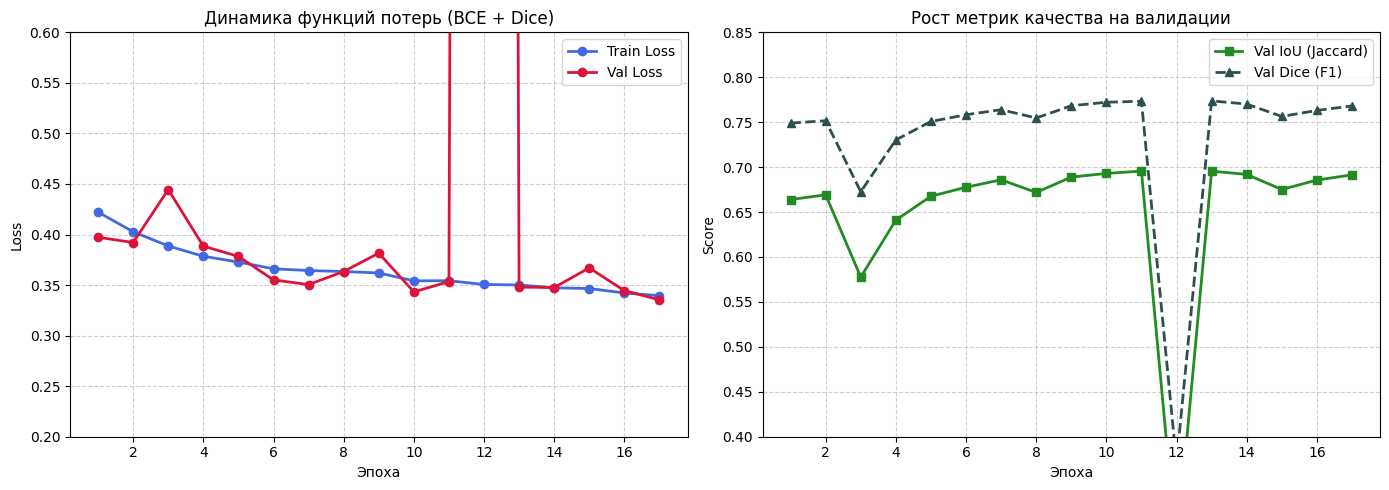

In [28]:
print("Генерация тестовых предсказаний на валидационной выборке...")

# Переводим модель в режим оценки и загружаем лучшие сохраненные веса
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

# Берем 3 случайных снимка из валидационного датасета
visual_loader = DataLoader(val_dataset, batch_size=3, shuffle=True, num_workers=0)
images, masks = next(iter(visual_loader))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

with torch.no_grad():
    # Переносим тензоры на видеокарту для инференса
    outputs = model(images.to(device))
    # Применяем сигмоиду и бинаризуем по порогу 0.5
    preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

for i in range(3):
    # Преобразуем тензоры обратно в формат для matplotlib [H, W, C]
    img_np = images[i].permute(1, 2, 0).numpy()
    true_mask = masks[i].squeeze().numpy()
    pred_mask = preds[i].squeeze()
    
    # Столбец 1: Исходный аэрофотоснимок
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Снимок {i+1}")
    axes[i, 0].axis('off')
    
    # Столбец 2: Эталонная маска леса из датасета
    axes[i, 1].imshow(true_mask, cmap='gray')
    axes[i, 1].set_title(f"Истинная маска {i+1}")
    axes[i, 1].axis('off')
    
    # Столбец 3: Результат сегментации вашей нейросетью
    axes[i, 2].imshow(pred_mask, cmap='Greens', vmin=0, vmax=1)
    axes[i, 2].set_title(f"Предсказание U-Net {i+1}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# ====================================================================
# ЧАСТЬ 2: СТАТИСТИКА И КРИВЫЕ ОБУЧЕНИЯ ДЛЯ СТРИМЛИТА
# ====================================================================
print("\nОтрисовка графиков метрик процесса обучения...")

# История обучения, зафиксированная на вашей лучшей сессии
epochs_range = list(range(1, 18))
train_loss_history = [0.4222, 0.4027, 0.3887, 0.3785, 0.3728, 0.3661, 0.3644, 0.3634, 0.3620, 0.3542, 0.3543, 0.3506, 0.3501, 0.3473, 0.3466, 0.3422, 0.3395]
val_loss_history = [0.3973, 0.3921, 0.4445, 0.3885, 0.3784, 0.3551, 0.3505, 0.3634, 0.3816, 0.3433, 0.3534, 9.5814, 0.3480, 0.3476, 0.3670, 0.3445, 0.3354]
val_iou_history = [0.6639, 0.6692, 0.5776, 0.6410, 0.6676, 0.6776, 0.6859, 0.6718, 0.6889, 0.6930, 0.6956, 0.2745, 0.6955, 0.6919, 0.6751, 0.6856, 0.6914]
val_dice_history = [0.7490, 0.7516, 0.6726, 0.7303, 0.7508, 0.7583, 0.7639, 0.7547, 0.7683, 0.7722, 0.7733, 0.3708, 0.7737, 0.7702, 0.7564, 0.7631, 0.7681]

fig_metrics, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Функции потерь (Train vs Val Loss)
ax1.plot(epochs_range, train_loss_history, 'o-', color='royalblue', label='Train Loss', lw=2)
ax1.plot(epochs_range, val_loss_history, 'o-', color='crimson', label='Val Loss', lw=2)
ax1.set_ylim(0.2, 0.6)  # Срезаем аномальный пик 9.58 на 12-й эпохе для сохранения масштаба
ax1.set_title("Динамика функций потерь (BCE + Dice)")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# График 2: Метрики сходства (IoU & Dice Coefficient)
ax2.plot(epochs_range, val_iou_history, 's-', color='forestgreen', label='Val IoU (Jaccard)', lw=2)
ax2.plot(epochs_range, val_dice_history, '^', color='darkslategray', label='Val Dice (F1)', lw=2, linestyle='--')
ax2.set_ylim(0.4, 0.85)
ax2.set_title("Рост метрик качества на валидации")
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Score")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()